# 循环矩阵

## 概述

本讲座将介绍循环矩阵及其一些性质。

循环矩阵之所以有用，是因为与它们相乘和卷积密切相关，并且它们的特征向量可以用离散傅里叶变换来构造。

我们用循环矩阵将几个有用的概念联系起来，包括

  * 卷积运算
  * 傅里叶变换
  * 置换矩阵

关于特征值和特征向量的背景知识，请参见 {doc}`linear_algebra`；关于傅里叶变换和卷积的另一个应用，请参见 {doc}`hoist_failure`。

循环矩阵在机器学习中也有广泛应用，例如在图像处理中。

我们首先导入一些Python包：

In [1]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']


In [2]:
np.set_printoptions(precision=3, suppress=True)

## 构造循环矩阵

要构造一个 $N \times N$ 的循环矩阵，我们只需要第一行，比如：

$$ \begin{bmatrix} c_{0} & c_{1} & c_{2} & c_{3} & c_{4} & \cdots & c_{N-1} \end{bmatrix} .$$

设置第一行的元素后，循环矩阵的其余行按以下方式确定：

$$
C=\left[\begin{array}{ccccccc}
c_{0} & c_{1} & c_{2} & c_{3} & c_{4} & \cdots & c_{N-1}\\
c_{N-1} & c_{0} & c_{1} & c_{2} & c_{3} & \cdots & c_{N-2}\\
c_{N-2} & c_{N-1} & c_{0} & c_{1} & c_{2} & \cdots & c_{N-3}\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
c_{3} & c_{4} & c_{5} & c_{6} & c_{7} & \cdots & c_{2}\\
c_{2} & c_{3} & c_{4} & c_{5} & c_{6} & \cdots & c_{1}\\
c_{1} & c_{2} & c_{3} & c_{4} & c_{5} & \cdots & c_{0}
\end{array}\right]
$$ (eqn:circulant)

这个模式可以形式化如下。

```{prf:definition} 循环矩阵
:label: def-circulant-matrix

一个 $N \times N$ 矩阵 $C$ 是**循环的**，如果存在数字 $c_0, \ldots, c_{N-1}$，使得

$$
C_{ij} = c_{(j-i) \bmod N},
\qquad 0 \leq i,j \leq N-1.
$$

等价地，每一行都是通过将上一行的元素向右移动一位而得到的。
```

也可以通过创建上述矩阵的转置来构造循环矩阵，在这种情况下只需要指定第一列。

让我们编写一些Python代码来生成循环矩阵：

In [3]:
def construct_circulant(row):

    N = row.size

    C = np.empty((N, N))

    for i in range(N):

        C[i, i:] = row[:N-i]
        C[i, :i] = row[N-i:]

    return C

In [4]:
# 当 N = 3 时的一个简单例子
construct_circulant(np.array([1., 2., 3.]))

array([[1., 2., 3.],
       [3., 1., 2.],
       [2., 3., 1.]])

### 循环矩阵的一些性质

以下是一些有用的性质：

假设 $A$ 和 $B$ 都是同阶的循环矩阵，并且采用相同的循环移位约定构造。

那么可以验证：

 * 循环矩阵的转置是循环矩阵

  * $A + B$ 是循环矩阵
  * $A B$ 是循环矩阵
  * $A B = B A$

现在考虑一个第一行为

  $$  c = \begin{bmatrix} c_0 & c_1 & \cdots & c_{N-1} \end{bmatrix} $$

的循环矩阵，并考虑一个向量

 $$ a = \begin{bmatrix} a_0 & a_1 & \cdots  &  a_{N-1} \end{bmatrix} $$

向量 $c$ 和 $a$ 的**卷积**定义为向量 $b = c * a $，其分量为

$$
 b_k = \sum_{i=0}^{N-1} c_{k-i} a_i
$$ (eqn:conv)

这里以及下文中，诸如 $k-i$ 之类的下标都按模 $N$ 来理解。

我们使用 $*$ 来表示通过方程 {eq}`eqn:conv` 描述的**卷积**计算。

可以验证向量 $b$ 满足

$$ b = C^\top a  $$

其中 $C^\top$ 是方程 {eq}`eqn:circulant` 中定义的循环矩阵的转置。

## 与置换矩阵的联系

构造循环矩阵的一个好方法是使用**置换矩阵**。

在定义置换**矩阵**之前，我们先定义**置换**。

非负整数集 $\{0, 1, 2, \ldots \}$ 的**置换**是该集合到自身的一一映射。

集合 $\{1, 2, \ldots, n\}$ 的置换重新排列了该集合中的 $n$ 个整数。

[置换矩阵](https://mathworld.wolfram.com/PermutationMatrix.html)是通过根据数字 $1$ 到 $n$ 的置换来置换 $n \times n$ 单位矩阵的行而获得的。

因此，每一行和每一列都恰好包含一个 $1$，其余位置都是 $0$。

每个置换都对应一个唯一的置换矩阵。

例如，$N \times N$ 矩阵

$$
P=\left[\begin{array}{cccccc}
0 & 1 & 0 & 0 & \cdots & 0\\
0 & 0 & 1 & 0 & \cdots & 0\\
0 & 0 & 0 & 1 & \cdots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
0 & 0 & 0 & 0 & \cdots & 1\\
1 & 0 & 0 & 0 & \cdots & 0
\end{array}\right]
$$ (eqn:exampleP)

是一个**循环移位**算子，当应用于 $N \times 1$ 向量 $h$ 时，将第 $2$ 行到第 $N$ 行的元素向上移动一行，并将第 $1$ 行的元素移动到第 $N$ 行。

方程 {eq}`eqn:exampleP` 中定义的循环移位置换矩阵 $P$ 的特征值可以通过构造

$$
P-\lambda I=\left[\begin{array}{cccccc}
-\lambda & 1 & 0 & 0 & \cdots & 0\\
0 & -\lambda & 1 & 0 & \cdots & 0\\
0 & 0 & -\lambda & 1 & \cdots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
0 & 0 & 0 & 0 & \cdots & 1\\
1 & 0 & 0 & 0 & \cdots & -\lambda
\end{array}\right]
$$

并求解

$$
\textrm{det}(P - \lambda I) = (-1)^N(\lambda^N - 1)=0
$$

来计算。

特征值 $\lambda_i$ 可以是复数。

这些特征值 $\lambda_i$ 的模 $\mid \lambda_i \mid$ 都等于 $1$。

因此，方程 {eq}`eqn:exampleP` 中定义的置换矩阵 $P$ 的**奇异值**都等于 $1$。

可以验证置换矩阵是正交矩阵：

$$
P P^\top = I
$$

## Python示例

让我们编写一些Python代码来说明这些概念：

In [5]:
def construct_cyclic_shift_matrix(N):

    P = np.zeros((N, N))

    for i in range(N-1):
        P[i, i+1] = 1
    P[-1, 0] = 1

    return P

In [6]:
P4 = construct_cyclic_shift_matrix(4)
P4

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]])

In [7]:
# 计算特征值和特征向量
𝜆, Q = np.linalg.eig(P4)

In [8]:
for i in range(4):
    print(f'𝜆{i} = {𝜆[i]:.1f} \nvec{i} = {Q[:, i]}\n')

𝜆0 = -1.0+0.0j 
vec0 = [-0.5+0.j  0.5+0.j -0.5+0.j  0.5+0.j]

𝜆1 = 0.0+1.0j 
vec1 = [ 0. -0.5j  0.5+0.j  -0. +0.5j -0.5-0.j ]

𝜆2 = 0.0-1.0j 
vec2 = [ 0. +0.5j  0.5-0.j  -0. -0.5j -0.5+0.j ]

𝜆3 = 1.0+0.0j 
vec3 = [-0.5+0.j -0.5+0.j -0.5+0.j -0.5+0.j]


在下面的图中，我们将在复平面上描绘移位置换矩阵的特征值。

这些特征值在单位圆上均匀分布。

它们是**$n$ 个单位根**，也就是说，它们是满足 $z^n =1$ 的 $n$ 个数 $z$，其中 $z$ 是复数。

具体来说，$n$ 个单位根为

$$
z = \exp\left(\frac{2 \pi j k }{N} \right) , \quad k = 0, \ldots, N-1
$$

其中 $j$ 表示纯虚数单位。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


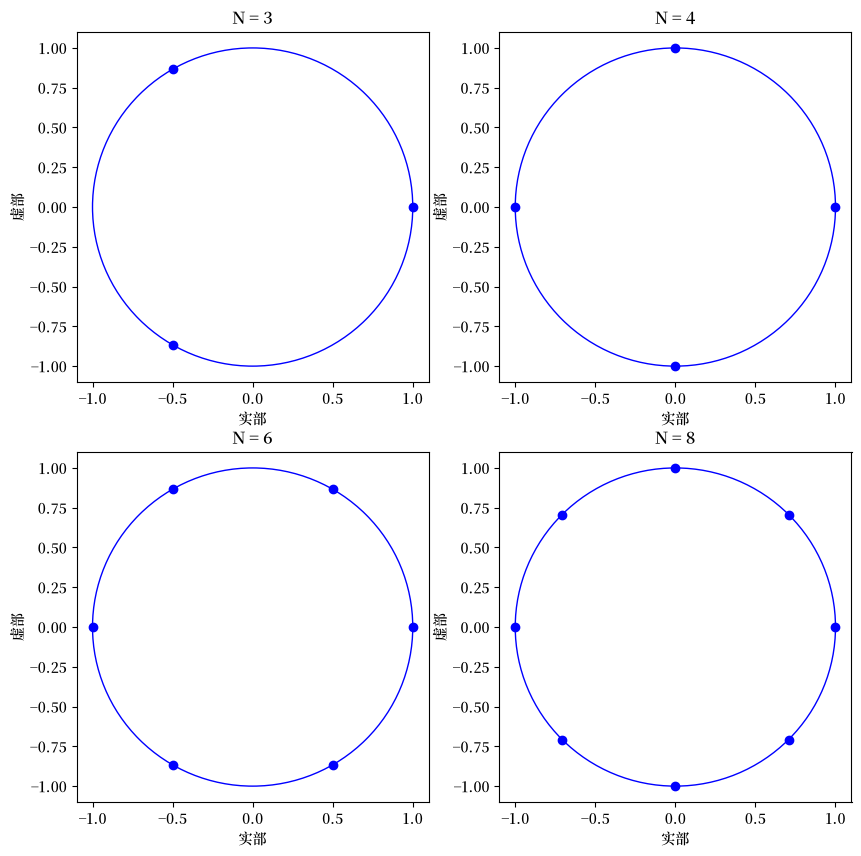

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

for i, N in enumerate([3, 4, 6, 8]):

    row_i = i // 2
    col_i = i % 2

    P = construct_cyclic_shift_matrix(N)
    𝜆, Q = np.linalg.eig(P)

    circ = plt.Circle((0, 0), radius=1, edgecolor='b', facecolor='None')
    ax[row_i, col_i].add_patch(circ)

    for j in range(N):
        ax[row_i, col_i].scatter(𝜆[j].real, 𝜆[j].imag, c='b')

    ax[row_i, col_i].set_title(f'N = {N}')
    ax[row_i, col_i].set_xlabel('实部')
    ax[row_i, col_i].set_ylabel('虚部')

plt.show()

对于系数向量 $\{c_i\}_{i=0}^{n-1}$，$P$ 的特征向量也是

$$
C = c_{0} I + c_{1} P + c_{2} P^{2} +\cdots + c_{N-1} P^{N-1}.
$$

的特征向量。

考虑一个例子，其中 $N=8$ 且 $w = e^{-2 \pi j / N}$。

可以验证 $P_{8}$ 的特征向量矩阵 $F_8$ 是

$$
F_{8}=\left[\begin{array}{ccccc}
1 & 1 & 1 & \cdots & 1\\
1 & w & w^{2} & \cdots & w^{7}\\
1 & w^{2} & w^{4} & \cdots & w^{14}\\
1 & w^{3} & w^{6} & \cdots & w^{21}\\
1 & w^{4} & w^{8} & \cdots & w^{28}\\
1 & w^{5} & w^{10} & \cdots & w^{35}\\
1 & w^{6} & w^{12} & \cdots & w^{42}\\
1 & w^{7} & w^{14} & \cdots & w^{49}
\end{array}\right]
$$

矩阵 $F_8$ 定义了一个[离散傅里叶变换](https://en.wikipedia.org/wiki/Discrete_Fourier_transform)。

为了将其转换为正交特征向量矩阵，我们可以简单地通过将每个元素除以 $\sqrt{8}$ 来归一化。

 * 仔细观察上面 $F_8$ 的第一列来理解这个事实

对应于每个特征向量的特征值按顺序是 $\{w^{j}\}_{j=0}^{7}$。

In [10]:
def construct_F(N):

    w = np.e ** (-complex(0, 2*np.pi/N))

    F = np.ones((N, N), dtype=complex)
    for i in range(1, N):
        F[i, 1:] = w ** (i * np.arange(1, N))

    return F, w

In [11]:
F8, w = construct_F(8)

In [12]:
w

(0.7071067811865476-0.7071067811865475j)

In [13]:
F8

array([[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   ,
         1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  0.707-0.707j,  0.   -1.j   , -0.707-0.707j,
        -1.   -0.j   , -0.707+0.707j, -0.   +1.j   ,  0.707+0.707j],
       [ 1.   +0.j   ,  0.   -1.j   , -1.   -0.j   , -0.   +1.j   ,
         1.   +0.j   ,  0.   -1.j   , -1.   -0.j   , -0.   +1.j   ],
       [ 1.   +0.j   , -0.707-0.707j, -0.   +1.j   ,  0.707-0.707j,
        -1.   -0.j   ,  0.707+0.707j,  0.   -1.j   , -0.707+0.707j],
       [ 1.   +0.j   , -1.   -0.j   ,  1.   +0.j   , -1.   -0.j   ,
         1.   +0.j   , -1.   -0.j   ,  1.   +0.j   , -1.   -0.j   ],
       [ 1.   +0.j   , -0.707+0.707j,  0.   -1.j   ,  0.707+0.707j,
        -1.   -0.j   ,  0.707-0.707j, -0.   +1.j   , -0.707-0.707j],
       [ 1.   +0.j   , -0.   +1.j   , -1.   -0.j   ,  0.   -1.j   ,
         1.   +0.j   , -0.   +1.j   , -1.   -0.j   ,  0.   -1.j   ],
       [ 1.   +0.j   ,  0.707+0.707j, -0.

In [14]:
# 归一化
Q8 = F8 / np.sqrt(8)

In [15]:
# 验证正交性（酉性）
Q8 @ np.conjugate(Q8)

array([[ 1.+0.j, -0.+0.j, -0.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [-0.-0.j,  1.+0.j, -0.+0.j, -0.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [-0.-0.j, -0.-0.j,  1.+0.j, -0.+0.j, -0.+0.j, -0.+0.j,  0.+0.j,
         0.+0.j],
       [-0.-0.j, -0.-0.j, -0.-0.j,  1.+0.j, -0.+0.j, -0.+0.j, -0.+0.j,
        -0.+0.j],
       [ 0.-0.j, -0.-0.j, -0.-0.j, -0.+0.j,  1.+0.j, -0.+0.j, -0.+0.j,
        -0.+0.j],
       [ 0.-0.j,  0.-0.j, -0.-0.j, -0.-0.j, -0.-0.j,  1.+0.j, -0.+0.j,
        -0.+0.j],
       [ 0.-0.j,  0.-0.j,  0.-0.j, -0.-0.j, -0.-0.j, -0.-0.j,  1.+0.j,
        -0.+0.j],
       [ 0.-0.j,  0.-0.j,  0.-0.j, -0.-0.j, -0.-0.j, -0.-0.j, -0.-0.j,
         1.+0.j]])

让我们验证 $Q_{8}$ 的第 $k$ 列是 $P_{8}$ 的特征向量，对应的特征值是 $w^{k}$。

In [16]:
P8 = construct_cyclic_shift_matrix(8)

In [17]:
diff_arr = np.empty(8, dtype=complex)
for j in range(8):
    diff = P8 @ Q8[:, j] - w ** j * Q8[:, j]
    diff_arr[j] = diff @ diff.T

In [18]:
diff_arr

array([ 0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j,
       -0.+0.j])

## 关联的置换矩阵

接下来，我们进行计算以验证方程 {eq}`eqn:circulant` 中定义的循环矩阵 $C$ 可以写成

$$
C = c_{0} I + c_{1} P + \cdots + c_{N-1} P^{N-1}
$$

并且 $P$ 的每个特征向量也是 $C$ 的特征向量。

我们用 $N=8$ 的情况来说明这一点。

In [19]:
c = np.random.random(8)

In [20]:
c

array([0.313, 0.005, 0.97 , 0.124, 0.037, 0.244, 0.568, 0.175])

In [21]:
C8 = construct_circulant(c)

计算 $c_{0} I + c_{1} P + \cdots + c_{N-1} P^{N-1}$。

In [22]:
N = 8

C = np.zeros((N, N))
P = np.eye(N)

for i in range(N):
    C += c[i] * P
    P = P8 @ P

In [23]:
C

array([[0.313, 0.005, 0.97 , 0.124, 0.037, 0.244, 0.568, 0.175],
       [0.175, 0.313, 0.005, 0.97 , 0.124, 0.037, 0.244, 0.568],
       [0.568, 0.175, 0.313, 0.005, 0.97 , 0.124, 0.037, 0.244],
       [0.244, 0.568, 0.175, 0.313, 0.005, 0.97 , 0.124, 0.037],
       [0.037, 0.244, 0.568, 0.175, 0.313, 0.005, 0.97 , 0.124],
       [0.124, 0.037, 0.244, 0.568, 0.175, 0.313, 0.005, 0.97 ],
       [0.97 , 0.124, 0.037, 0.244, 0.568, 0.175, 0.313, 0.005],
       [0.005, 0.97 , 0.124, 0.037, 0.244, 0.568, 0.175, 0.313]])

In [24]:
C8

array([[0.313, 0.005, 0.97 , 0.124, 0.037, 0.244, 0.568, 0.175],
       [0.175, 0.313, 0.005, 0.97 , 0.124, 0.037, 0.244, 0.568],
       [0.568, 0.175, 0.313, 0.005, 0.97 , 0.124, 0.037, 0.244],
       [0.244, 0.568, 0.175, 0.313, 0.005, 0.97 , 0.124, 0.037],
       [0.037, 0.244, 0.568, 0.175, 0.313, 0.005, 0.97 , 0.124],
       [0.124, 0.037, 0.244, 0.568, 0.175, 0.313, 0.005, 0.97 ],
       [0.97 , 0.124, 0.037, 0.244, 0.568, 0.175, 0.313, 0.005],
       [0.005, 0.97 , 0.124, 0.037, 0.244, 0.568, 0.175, 0.313]])

现在让我们计算两种不同方式构造的循环矩阵之间的差值。

In [25]:
np.abs(C - C8).max()

np.float64(0.0)

$Q_{8}$ 的第 $j$ 列是 $C_{8}$ 的特征向量，其关联的特征值为 $\sum_{k=0}^{7} c_k w^{j k}$。

In [26]:
𝜆_C8 = np.zeros(8, dtype=complex)

for j in range(8):
    for k in range(8):
        𝜆_C8[j] += c[k] * w ** (j * k)

In [27]:
𝜆_C8

array([ 2.436+0.j   ,  0.142-0.198j, -1.189+0.05j ,  0.409+0.606j,
        1.34 +0.j   ,  0.409-0.606j, -1.189-0.05j ,  0.142+0.198j])

我们可以通过比较 `C8 @ Q8[:, j]` 和 `𝜆_C8[j] * Q8[:, j]` 来验证这一点。

In [28]:
# 验证
for j in range(8):
    diff = C8 @ Q8[:, j] - 𝜆_C8[j] * Q8[:, j]
    print(diff)

[ 0.+0.j -0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
[ 0.+0.j  0.-0.j  0.-0.j -0.-0.j -0.-0.j -0.+0.j -0.-0.j -0.-0.j]
[ 0.+0.j  0.-0.j -0.-0.j -0.-0.j  0.+0.j  0.-0.j  0.-0.j -0.+0.j]
[ 0.-0.j -0.-0.j -0.-0.j -0.+0.j  0.+0.j -0.-0.j -0.-0.j -0.+0.j]
[ 0.+0.j  0.-0.j -0.-0.j  0.+0.j  0.-0.j  0.+0.j -0.-0.j  0.+0.j]
[ 0.+0.j -0.-0.j  0.-0.j  0.+0.j -0.-0.j  0.-0.j  0.-0.j  0.+0.j]
[-0.+0.j -0.-0.j  0.-0.j  0.+0.j  0.+0.j -0.-0.j  0.-0.j  0.+0.j]
[0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.+0.j 0.-0.j 0.-0.j]


## 离散傅里叶变换

**离散傅里叶变换**（DFT）允许我们将离散时间序列表示为复正弦波的加权和。

考虑一个包含 $N$ 个实数的序列 $\{x_j\}_{j=0}^{N-1}$。

**离散傅里叶变换**将 $\{x_j\}_{j=0}^{N-1}$ 映射到复数序列 $\{X_k\}_{k=0}^{N-1}$，其中

$$
X_{k}=\sum_{n=0}^{N-1}x_{n}e^{-2\pi\frac{kn}{N}i}
$$

In [29]:
def DFT(x):
    "离散傅里叶变换。"

    N = len(x)
    w = np.e ** (-complex(0, 2*np.pi/N))

    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * w ** (k * n)

    return X

考虑以下示例：

$$
x_{n}=\begin{cases}
1/2 & n=0,1\\
0 & \text{其他情况}
\end{cases}
$$

In [30]:
x = np.zeros(10)
x[0:2] = 1/2

In [31]:
x

array([0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

应用离散傅里叶变换。

In [32]:
X = DFT(x)

In [33]:
X

array([ 1.   +0.j   ,  0.905-0.294j,  0.655-0.476j,  0.345-0.476j,
        0.095-0.294j, -0.   +0.j   ,  0.095+0.294j,  0.345+0.476j,
        0.655+0.476j,  0.905+0.294j])

我们可以绘制数字序列的幅值和相关的离散傅里叶变换。

In [34]:
def plot_magnitude(x=None, X=None):

    data = []
    names = []
    xs = []
    if (x is not None):
        data.append(x)
        names.append('x')
        xs.append('n')
    if (X is not None):
        data.append(X)
        names.append('X')
        xs.append('k')

    num = len(data)
    for i in range(num):
        n = data[i].size
        plt.figure(figsize=(8, 3))
        plt.scatter(range(n), np.abs(data[i]))
        plt.vlines(range(n), 0, np.abs(data[i]), color='b')

        plt.xlabel(xs[i])
        plt.ylabel('幅值')
        plt.title(names[i])
        plt.show()

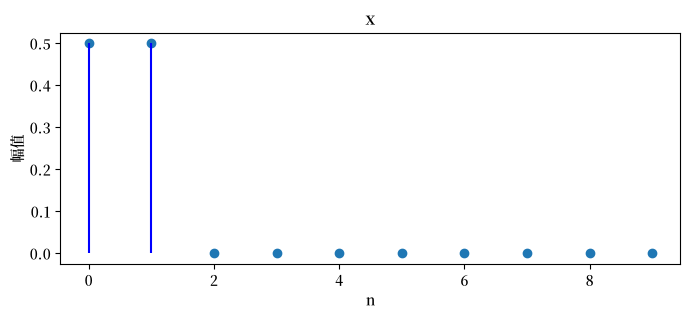

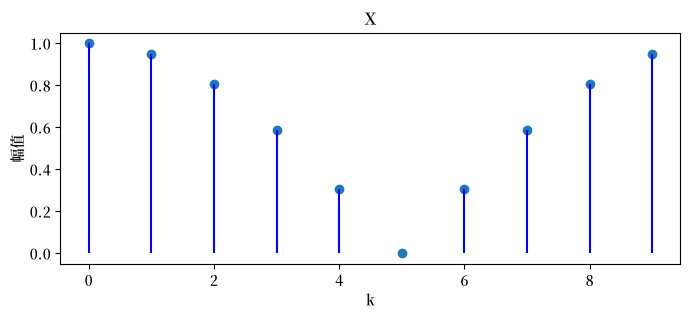

In [35]:
plot_magnitude(x=x, X=X)

**逆傅里叶变换**将 $x$ 的傅里叶变换 $X$ 转换回 $x$。

逆傅里叶变换定义为

$$
x_{n} = \sum_{k=0}^{N-1} \frac{1}{N} X_{k} e^{2\pi\left(\frac{kn}{N}\right)i}, \quad n=0, 1, \ldots, N-1
$$

In [36]:
def inverse_DFT(X):

    N = len(X)
    w = np.e ** (complex(0, 2*np.pi/N))

    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * w ** (k * n) / N

    return x

In [37]:
inverse_DFT(X)

array([ 0.5+0.j,  0.5-0.j, -0. -0.j, -0. -0.j, -0. -0.j, -0. -0.j,
       -0. +0.j, -0. +0.j, -0. +0.j, -0. +0.j])

另一个例子是

$$
x_{n}=2\cos\left(2\pi\frac{11}{40}n\right),\ n=0,1,2,\cdots19
$$

由于 $N=20$，我们不能使用 $\frac{1}{20}$ 的整数倍来表示频率 $\frac{11}{40}$。

为了处理这种情况，我们最终将使用DFT中所有可用的 $N$ 个频率。

由于 $\frac{11}{40}$ 在 $\frac{10}{40}$ 和 $\frac{12}{40}$ 之间（每个都是 $\frac{1}{20}$ 的整数倍），DFT中的复系数在 $k=5,6,15,16$ 处具有最大幅值，而不仅仅是在单个频率处。

In [38]:
N = 20
x = np.empty(N)

for j in range(N):
    x[j] = 2 * np.cos(2 * np.pi * 11 * j / 40)

In [39]:
X = DFT(x)

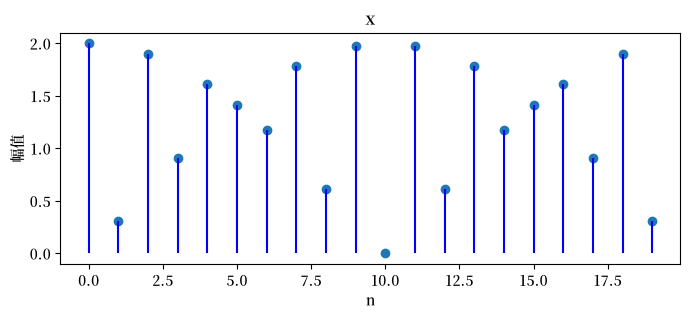

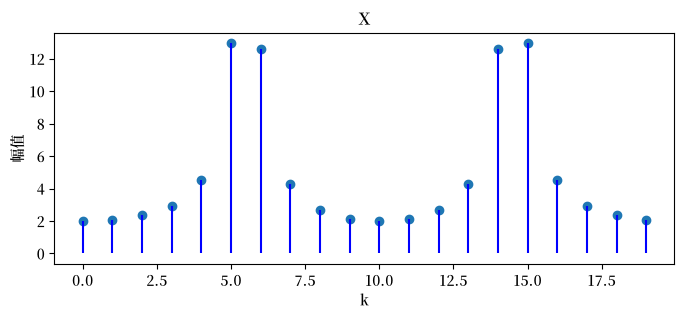

In [40]:
plot_magnitude(x=x, X=X)

如果我们把最后一个例子改为 $x_{n}=2\cos\left(2\pi\frac{10}{40}n\right)$ 会发生什么？

注意 $\frac{10}{40}$ 是 $\frac{1}{20}$ 的整数倍。

In [41]:
N = 20
x = np.empty(N)

for j in range(N):
    x[j] = 2 * np.cos(2 * np.pi * 10 * j / 40)

In [42]:
X = DFT(x)

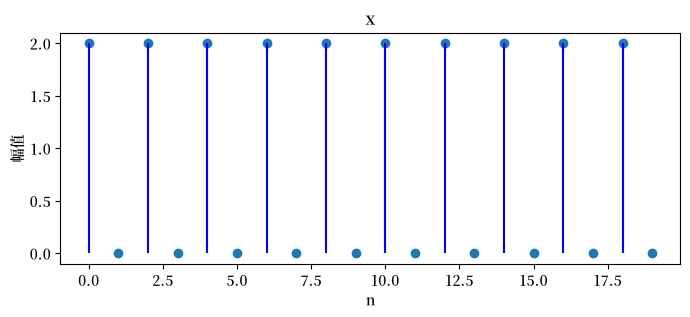

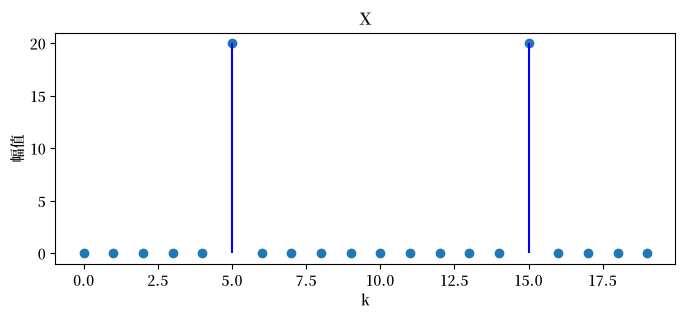

In [43]:
plot_magnitude(x=x, X=X)

如果我们将离散傅里叶变换表示为矩阵，我们会发现它等于置换矩阵 $P_{N}$ 的特征向量矩阵 $F_{N}$。

我们可以使用 $x_{n}=2\cos\left(2\pi\frac{11}{40}n\right),\ n=0,1,2,\cdots19$ 的例子来说明这一点。

In [44]:
N = 20
x = np.empty(N)

for j in range(N):
    x[j] = 2 * np.cos(2 * np.pi * 11 * j / 40)

In [45]:
x

array([ 2.   , -0.313, -1.902,  0.908,  1.618, -1.414, -1.176,  1.782,
        0.618, -1.975, -0.   ,  1.975, -0.618, -1.782,  1.176,  1.414,
       -1.618, -0.908,  1.902,  0.313])

首先使用求和公式将 $x$ 变换为 $X$。

In [46]:
X = DFT(x)
X

array([2. +0.j   , 2. +0.558j, 2. +1.218j, 2. +2.174j, 2. +4.087j,
       2.+12.785j, 2.-12.466j, 2. -3.751j, 2. -1.801j, 2. -0.778j,
       2. -0.j   , 2. +0.778j, 2. +1.801j, 2. +3.751j, 2.+12.466j,
       2.-12.785j, 2. -4.087j, 2. -2.174j, 2. -1.218j, 2. -0.558j])

现在让我们计算特征向量矩阵 $F_{20}$ 与向量 $x$ 的后乘结果，这个乘积应该等于序列 $\{x_n\}_{n=0}^{N-1}$ 的傅里叶变换。

In [47]:
F20, _ = construct_F(20)

In [48]:
F20 @ x

array([2. +0.j   , 2. +0.558j, 2. +1.218j, 2. +2.174j, 2. +4.087j,
       2.+12.785j, 2.-12.466j, 2. -3.751j, 2. -1.801j, 2. -0.778j,
       2. -0.j   , 2. +0.778j, 2. +1.801j, 2. +3.751j, 2.+12.466j,
       2.-12.785j, 2. -4.087j, 2. -2.174j, 2. -1.218j, 2. -0.558j])

同样，逆DFT可以表示为逆DFT矩阵 $F^{-1}_{20}$。

In [49]:
F20_inv = np.linalg.inv(F20)
F20_inv @ X

array([ 2.   -0.j, -0.313+0.j, -1.902-0.j,  0.908-0.j,  1.618-0.j,
       -1.414-0.j, -1.176+0.j,  1.782-0.j,  0.618-0.j, -1.975-0.j,
       -0.   +0.j,  1.975-0.j, -0.618-0.j, -1.782+0.j,  1.176+0.j,
        1.414-0.j, -1.618-0.j, -0.908+0.j,  1.902+0.j,  0.313-0.j])